📂 Mengambil data dari: /content/datalatih.xlsx dan /content/dataoutput.csv...
✅ File berhasil dibaca!

⚖️ Sedang melakukan Data Augmentation...
✅ Data Augmentation Selesai! Total Data Latih: 471 baris.

🧠 Melatih Model Random Forest...

📊 HASIL AKURASI MODEL: 88.42%
              precision    recall  f1-score   support

     Bulanan       0.89      0.86      0.88        37
      Harian       0.86      0.86      0.86        14
    Mingguan       0.74      0.82      0.78        17
     Tahunan       1.00      0.96      0.98        27

    accuracy                           0.88        95
   macro avg       0.87      0.88      0.87        95
weighted avg       0.89      0.88      0.89        95



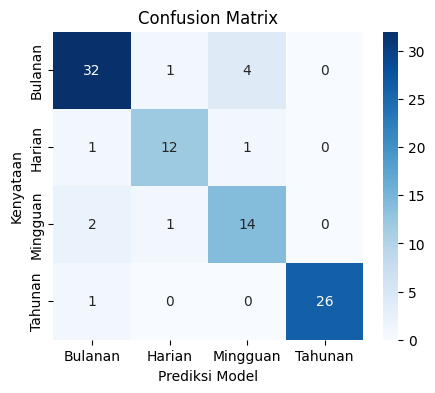


📱 APLIKASI REKOMENDASI PAKET (VERSI COLAB)
Silakan tes input data di bawah ini (Ketik 'exit' di budget untuk berhenti).

💰 Masukkan Budget (Rp): 12000
🌐 Masukkan Butuh Kuota (GB): 5

🔍 [Analisis RF] User diprediksi masuk kategori: HARIAN
⭐ Skor Kecocokan (Confidence): 76%
----------------------------------------
#1 Internet Harian
   Harga: Rp 18,000 | Kuota: 5.5 GB | Masa Aktif: 3 Hari
#2 Serbu
   Harga: Rp 7,000 | Kuota: 7.0 GB | Masa Aktif: 1 Hari
#3 Internet Harian
   Harga: Rp 7,000 | Kuota: 7.0 GB | Masa Aktif: 1 Hari
----------------------------------------

💰 Masukkan Budget (Rp): 12000
🌐 Masukkan Butuh Kuota (GB): 15

🔍 [Analisis RF] User diprediksi masuk kategori: HARIAN
⭐ Skor Kecocokan (Confidence): 78%
----------------------------------------
#1 Serbu
   Harga: Rp 7,000 | Kuota: 7.0 GB | Masa Aktif: 1 Hari
#2 Internet Harian
   Harga: Rp 7,000 | Kuota: 7.0 GB | Masa Aktif: 1 Hari
#3 Serbu
   Harga: Rp 5,000 | Kuota: 7.0 GB | Masa Aktif: 1 Hari
----------------------------

In [ ]:
import pandas as pd
import numpy as np
import re
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.ensemble import RandomForestClassifier
from sklearn.neighbors import NearestNeighbors
from sklearn.preprocessing import LabelEncoder, MinMaxScaler
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score

PATH_LATIH = "/content/datalatih.xlsx"
PATH_PAKET = "/content/dataoutput.csv"

print(f" Mengambil data dari: {PATH_LATIH} dan {PATH_PAKET}...")

def clean_money(x):
    if pd.isna(x): return 0
    x = str(x).lower().replace('rp','').replace('.','').replace(',','').replace(' ','')
    if 'k' in x: x = x.replace('k','000')
    try: return float(re.findall(r"[\d]+", x)[0])
    except: return 0

def clean_quota(x):
    if pd.isna(x): return 0
    x = str(x).lower().replace('gb','').replace(' ','')
    if 'unlimited' in x: return 999
    try:
        if '-' in x: a, b = x.split('-'); return (float(a)+float(b))/2
        return float(re.findall(r"[\d\.]+", x)[0])
    except: return 0

def tag_paket(days):
    try:
        days = float(days)
        if days <= 3: return 'Harian'
        elif days <= 14: return 'Mingguan'
        elif days <= 60: return 'Bulanan'
        else: return 'Tahunan'
    except: return 'Lainnya'

try:
    try:
        df_train = pd.read_excel(PATH_LATIH)
    except:
        df_train = pd.read_csv(PATH_LATIH)

    df_paket = pd.read_csv(PATH_PAKET, header=1)
    print(" File berhasil dibaca!")

except FileNotFoundError:
    print(" ERROR: File tidak ditemukan di path /content/.")
    print("Pastikan file sudah ada di folder icon folder di sebelah kiri colab.")
    raise 

df_train['quota_clean'] = df_train.iloc[:, 5].apply(clean_quota)
df_train['budget_clean'] = df_train.iloc[:, 6].apply(clean_money)
df_train['target_preference'] = df_train.iloc[:, 7].astype(str).str.title().str.strip()

valid_cats = ['Harian', 'Mingguan', 'Bulanan', 'Tahunan']
df_train = df_train[df_train['target_preference'].isin(valid_cats)].copy()

df_paket['quota_clean'] = df_paket['kuota_gb'].apply(clean_quota)
df_paket['price_clean'] = df_paket['harga_rupiah'].apply(clean_money)
df_paket['kategori_paket'] = df_paket['masa_aktif_hari'].apply(tag_paket)
df_paket = df_paket[(df_paket['quota_clean'] > 0) & (df_paket['price_clean'] > 0)].copy()

print("\n⚖️ Sedang melakukan Data Augmentation...")
stats_paket = df_paket.groupby('kategori_paket').agg({
    'price_clean': ['min', 'max'],
    'quota_clean': ['min', 'max']
})

dummy_data = []
for kategori in stats_paket.index:
    if kategori not in valid_cats: continue
    min_price = stats_paket.loc[kategori, ('price_clean', 'min')]
    max_price = stats_paket.loc[kategori, ('price_clean', 'max')]
    min_quota = stats_paket.loc[kategori, ('quota_clean', 'min')]
    max_quota = stats_paket.loc[kategori, ('quota_clean', 'max')]

    lower_factor = 0.8; upper_factor = 1.5
    if kategori == 'Tahunan': upper_factor = 20.0

    for _ in range(100):
        simulasi_quota = np.random.uniform(min_quota * 0.9, max_quota * 1.1)
        simulasi_budget = np.random.uniform(min_price * lower_factor, max_price * upper_factor)
        dummy_data.append({
            'quota_clean': simulasi_quota,
            'budget_clean': simulasi_budget,
            'target_preference': kategori
        })

df_add = pd.DataFrame(dummy_data)
df_train_balanced = pd.concat([df_train, df_add], ignore_index=True).ffill()
print(f" Data Augmentation Selesai! Total Data Latih: {len(df_train_balanced)} baris.")

X = df_train_balanced[['quota_clean', 'budget_clean']]
y = df_train_balanced['target_preference']

le = LabelEncoder()
y_encoded = le.fit_transform(y)

X_train, X_test, y_train, y_test = train_test_split(X, y_encoded, test_size=0.2, random_state=42)

print("\n Melatih Model Rndom Forest...")
rf = RandomForestClassifier(n_estimators=200, max_depth=20, random_state=42)
rf.fit(X_train, y_train)

y_pred = rf.predict(X_test)
acc = accuracy_score(y_test, y_pred)

print("\n" + "="*40)
print(f" HASIL AKURASI MODEL: {acc * 100:.2f}%")
print("="*40)
print(classification_report(y_test, y_pred, target_names=le.classes_))

plt.figure(figsize=(5,4))
sns.heatmap(confusion_matrix(y_test, y_pred), annot=True, fmt='d', cmap='Blues',
            xticklabels=le.classes_, yticklabels=le.classes_)
plt.title('Confusion Matrix')
plt.ylabel('Kenyataan'); plt.xlabel('Prediksi Model')
plt.show()

print("\n" + "="*50)
print(" APLIKASI REKOMENDASI PAKET (VERSI COLAB)")
print("="*50)

def simulasi_sistem(user_budget, user_quota):
    input_vector = pd.DataFrame([[user_quota, user_budget]], columns=['quota_clean', 'budget_clean'])
    pred_idx = rf.predict(input_vector)[0]
    kategori = le.inverse_transform([pred_idx])[0]

    if user_quota <= 5 and kategori in ['Bulanan', 'Tahunan']: kategori = 'Harian'
    elif user_quota <= 15 and kategori == 'Tahunan': kategori = 'Bulanan'

    print(f"\n [Analisis RF] User diprediksi masuk kategori: {kategori.upper()}")

    calon_paket = df_paket[df_paket['kategori_paket'] == kategori].copy()
    if len(calon_paket) == 0: calon_paket = df_paket.copy()

    scaler = MinMaxScaler()
    X_paket = calon_paket[['quota_clean', 'price_clean']].values
    X_user = np.array([[user_quota, user_budget]])

    scaler.fit(X_paket)
    X_paket_scaled = scaler.transform(X_paket)
    X_user_scaled = scaler.transform(X_user)

    knn = NearestNeighbors(n_neighbors=3, metric='euclidean')
    knn.fit(X_paket_scaled)
    distances, indices = knn.kneighbors(X_user_scaled)

    best_idx = indices[0][0]
    best_paket = calon_paket.iloc[best_idx]

    harga_real = float(best_paket['price_clean'])
    kuota_real = float(best_paket['quota_clean'])

    if harga_real <= user_budget: score_harga = 100
    else:
        selisih = harga_real - user_budget
        score_harga = 100 * (1 - (selisih / harga_real))

    pembagi_kuota = max(user_quota, kuota_real)
    if pembagi_kuota == 0: score_kuota = 0
    else: score_kuota = 100 * (1 - (abs(user_quota - kuota_real) / pembagi_kuota))

    final_score = (score_harga * 0.6) + (score_kuota * 0.4)
    final_score = int(min(max(final_score, 10), 99))
    if abs(harga_real - user_budget) < 5000 and abs(kuota_real - user_quota) < 1: final_score = 99

    print(f" Skor Kecocokan (Confidence): {final_score}%")
    print("-" * 40)

    hasil = calon_paket.iloc[indices[0]]
    rank = 1
    for _, row in hasil.iterrows():
        print(f"#{rank} {row['nama_paket']}")
        print(f"   Harga: Rp {int(row['price_clean']):,} | Kuota: {row['quota_clean']} GB | Masa Aktif: {row['masa_aktif_hari']} Hari")
        rank += 1
    print("-" * 40)

print("Silakan tes input data di bawah ini (Ketik 'exit' di budget untuk berhenti).")

while True:
    try:
        in_budget = input("\n Masukkan Budget (Rp): ")
        if in_budget.lower() == 'exit':
            print("Terima kasih, sistem berhenti.")
            break

        in_quota = input(" Masukkan Butuh Kuota (GB): ")

        simulasi_sistem(float(in_budget), float(in_quota))

    except ValueError:
        print("⚠️ Masukkan angka saja! Jangan pakai huruf.")
    except Exception as e:
        print(f"Error: {e}")